# Compare twin-pair gene-gene correlations at t1 vs t2

For each BoolODE simulation type (mCAD, HSC, VSC, GSD), TwINFER inference was run
per replicate and saved to `analysis_data/boolode_sims/twinfer_inference/<sim_type>_rep_<n>_all_results.json`.
Each record contains `twin_pair_correlation_matrix_t1` / `_t2`: gene x gene twin-pair
correlation matrices computed at the early (t1) and late (t2) timepoints.

This notebook:
1. Loads every gene-pair's t1/t2 twin correlation, for every replicate, into one long-format table.
2. Runs a **paired Wilcoxon signed-rank test** (paired across replicates) comparing t1 vs t2
   correlation for **each gene pair**, within each sim_type.
3. Runs one pooled paired Wilcoxon test per sim_type (all gene pairs x replicates together) to ask
   whether t1 and t2 correlations differ systematically overall.
4. Saves all tables to CSV and gives a quick visual summary.


In [1]:
import glob
import itertools
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

In [2]:
path_to_inference_results = "/home/gzu5140/Keerthana_b1042/TwINFER/analysis_data/boolode_sims/twinfer_inference/"
path_to_save_outputs = os.path.join(path_to_inference_results, "twin_corr_t1_t2_comparison")
os.makedirs(path_to_save_outputs, exist_ok=True)

## Load t1/t2 twin correlation matrices into a long-format table

In [3]:
def load_corr_matrix(entry):
    """Reconstruct a pandas DataFrame from the {__type__, index, columns, data} dict
    format used by build_simulation_record's make_json_safe (see
    infer_network_simulation_boolode_sims.py)."""
    return pd.DataFrame(entry["data"], index=entry["index"], columns=entry["columns"])


def load_long_table(input_dir):
    rows = []
    files = sorted(glob.glob(os.path.join(input_dir, "*_all_results.json")))
    if not files:
        raise FileNotFoundError(f"No *_all_results.json files found in {input_dir}")

    for fpath in files:
        with open(fpath) as fh:
            d = json.load(fh)

        sim_type = d["sim_type"]
        rep_id = d["rep_id"]
        genes = d["gene_names"]

        t1 = load_corr_matrix(d["twin_pair_correlation_matrix_t1"])
        t2 = load_corr_matrix(d["twin_pair_correlation_matrix_t2"])

        for g1, g2 in itertools.combinations(genes, 2):
            rows.append({
                "sim_type": sim_type,
                "rep_id": rep_id,
                "gene1": g1,
                "gene2": g2,
                "t1_corr": t1.loc[g1, g2],
                "t2_corr": t2.loc[g1, g2],
            })

    long_df = pd.DataFrame(rows)
    long_df["diff"] = long_df["t2_corr"] - long_df["t1_corr"]
    return long_df


long_df = load_long_table(path_to_inference_results)
long_df.to_csv(os.path.join(path_to_save_outputs, "long_twin_correlation_t1_t2.csv"), index=False)
print(f"{len(long_df)} rows across {long_df['sim_type'].nunique()} sim types")
long_df.head()

1956 rows across 4 sim types


,sim_type,rep_id,gene1,gene2,t1_corr,t2_corr,diff
0,GSD,0,UGR,CBX2,0.014959,-0.021431,-0.036390
1,GSD,0,UGR,PGD2,-0.012578,-0.020731,-0.008153
2,GSD,0,UGR,DMRT1,-0.004642,0.025566,0.030208
3,GSD,0,UGR,DHH,-0.016192,0.013225,0.029416
4,GSD,0,UGR,DKK1,0.030322,-0.006423,-0.036746


## Paired Wilcoxon signed-rank test: t1 vs t2

Two levels of testing:
- **Per gene pair** (within each sim_type): pairs the t1/t2 values across replicates
  (n = 10 reps for mCAD/HSC/VSC, n = 6 for GSD). Tests whether that specific edge's twin
  correlation shifts between t1 and t2.
- **Pooled per sim_type**: pairs t1/t2 across *all* (gene pair, replicate) combinations at once,
  to ask whether correlations shift systematically overall for that network.


In [4]:
def paired_wilcoxon(x, y):
    """Wilcoxon signed-rank test on paired arrays x, y. Returns (stat, pvalue)."""
    x = np.asarray(x)
    y = np.asarray(y)
    if len(x) < 1 or np.allclose(x, y):
        return np.nan, np.nan  # all differences zero (or no data) -- wilcoxon() would raise
    try:
        stat, p = wilcoxon(x, y)
    except ValueError:
        return np.nan, np.nan
    return stat, p

In [5]:
def run_per_gene_pair_tests(long_df):
    results = []
    for (sim_type, g1, g2), grp in long_df.groupby(["sim_type", "gene1", "gene2"]):
        stat, p = paired_wilcoxon(grp["t1_corr"], grp["t2_corr"])
        results.append({
            "sim_type": sim_type,
            "gene1": g1,
            "gene2": g2,
            "n_reps": len(grp),
            "mean_t1_corr": grp["t1_corr"].mean(),
            "mean_t2_corr": grp["t2_corr"].mean(),
            "mean_diff": grp["diff"].mean(),
            "wilcoxon_stat": stat,
            "p_value": p,
        })
    res_df = pd.DataFrame(results)
    return res_df.sort_values(["sim_type", "p_value"]).reset_index(drop=True)


per_pair_df = run_per_gene_pair_tests(long_df)
per_pair_df.to_csv(os.path.join(path_to_save_outputs, "wilcoxon_per_gene_pair.csv"), index=False)
per_pair_df.head(10)

,sim_type,gene1,gene2,n_reps,mean_t1_corr,mean_t2_corr,mean_diff,wilcoxon_stat,p_value
0,GSD,AMH,FGF9,6,0.293937,0.034061,-0.259876,0.0,0.03125
1,GSD,AMH,NR0B1,6,-0.380515,-0.050687,0.329828,0.0,0.03125
2,GSD,DHH,AMH,6,0.279237,0.016340,-0.262897,0.0,0.03125
3,GSD,DHH,CTNNB1,6,0.003523,-0.019543,-0.023065,0.0,0.03125
4,GSD,DHH,FGF9,6,0.324691,0.045839,-0.278851,0.0,0.03125
5,GSD,DHH,NR0B1,6,-0.279257,-0.051165,0.228092,0.0,0.03125
6,GSD,DHH,RSPO1,6,0.001769,-0.023075,-0.024845,0.0,0.03125
7,GSD,DMRT1,DHH,6,-0.003223,0.026830,0.030053,0.0,0.03125
8,GSD,FOXL2,FGF9,6,-0.000344,-0.019351,-0.019007,0.0,0.03125
9,GSD,FOXL2,NR5A1,6,-0.006781,-0.036318,-0.029537,0.0,0.03125


In [6]:
def run_overall_tests(long_df):
    results = []
    for sim_type, grp in long_df.groupby("sim_type"):
        stat, p = paired_wilcoxon(grp["t1_corr"], grp["t2_corr"])
        results.append({
            "sim_type": sim_type,
            "n_pairs_x_reps": len(grp),
            "mean_t1_corr": grp["t1_corr"].mean(),
            "mean_t2_corr": grp["t2_corr"].mean(),
            "mean_diff": grp["diff"].mean(),
            "wilcoxon_stat": stat,
            "p_value": p,
        })
    return pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)


overall_df = run_overall_tests(long_df)
overall_df.to_csv(os.path.join(path_to_save_outputs, "wilcoxon_overall_per_sim_type.csv"), index=False)
overall_df

,sim_type,n_pairs_x_reps,mean_t1_corr,mean_t2_corr,mean_diff,wilcoxon_stat,p_value
0,mCAD,100,0.002494,-0.006042,-0.008536,1904.0,0.032745
1,GSD,1026,0.004342,-0.000769,-0.005111,244318.0,0.044157
2,HSC,550,0.002598,0.001181,-0.001418,72855.0,0.435518
3,VSC,280,0.003119,0.001510,-0.001610,18939.0,0.589869


In [11]:
per_pair_df[per_pair_df['sim_type'] == "HSC"]

,sim_type,gene1,gene2,n_reps,mean_t1_corr,mean_t2_corr,mean_diff,wilcoxon_stat,p_value
171,HSC,Fog1,EgrNab,10,0.025199,-0.006400,-0.031599,0.0,0.001953
172,HSC,Gfi1,Cebpa,10,0.012049,0.052911,0.040862,5.0,0.019531
173,HSC,Pu1,EgrNab,10,-0.003376,0.027235,0.030612,7.0,0.037109
174,HSC,Fog1,Cebpa,10,0.000620,0.014070,0.013450,8.0,0.048828
175,HSC,Gata2,cJun,10,0.006409,-0.020194,-0.026603,9.0,0.064453
176,HSC,Gata2,EgrNab,10,0.000485,-0.005639,-0.006124,13.0,0.160156
177,HSC,Fli1,EgrNab,10,0.006232,-0.012679,-0.018911,14.0,0.193359
178,HSC,Gata1,Fli1,10,-0.011511,0.002611,0.014123,14.0,0.193359
179,HSC,Scl,cJun,10,0.013747,-0.006811,-0.020558,14.0,0.193359
180,HSC,cJun,EgrNab,10,0.024569,0.035448,0.010879,14.0,0.193359


In [7]:
for sim_type in per_pair_df["sim_type"].unique():
    sub = per_pair_df[per_pair_df["sim_type"] == sim_type]
    n_sig = (sub["p_value"] < 0.05).sum()
    print(f"{sim_type}: {n_sig} / {len(sub)} gene pairs significant (p < 0.05)")

GSD: 18 / 171 gene pairs significant (p < 0.05)
HSC: 4 / 55 gene pairs significant (p < 0.05)
VSC: 0 / 28 gene pairs significant (p < 0.05)
mCAD: 3 / 10 gene pairs significant (p < 0.05)


## Quick visual summary

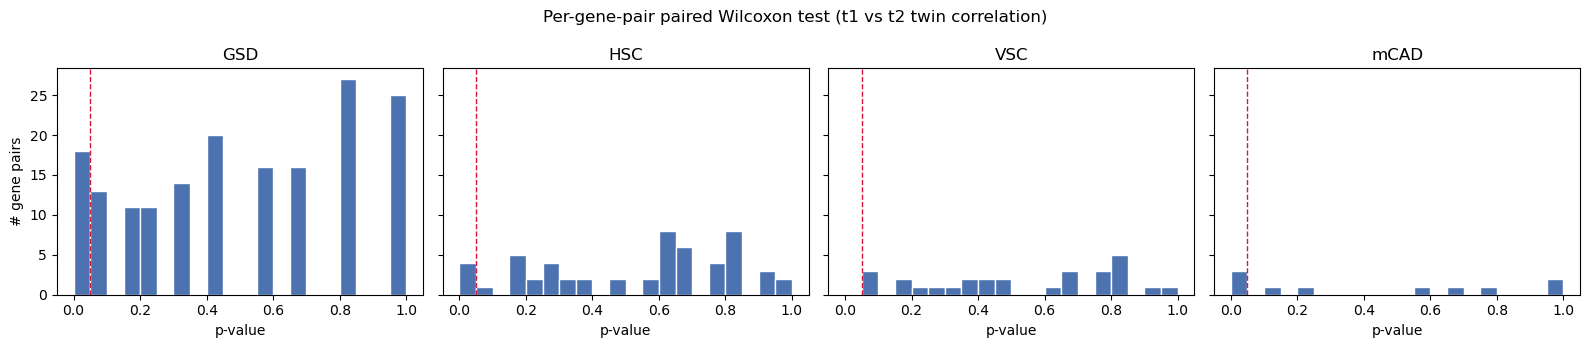

In [8]:
sim_types = per_pair_df["sim_type"].unique()
fig, axes = plt.subplots(1, len(sim_types), figsize=(4 * len(sim_types), 3.5), sharey=True)
for ax, sim_type in zip(axes, sim_types):
    sub = per_pair_df[per_pair_df["sim_type"] == sim_type]
    ax.hist(sub["p_value"].dropna(), bins=20, range=(0, 1), color="#4C72B0", edgecolor="white")
    ax.axvline(0.05, color="crimson", linestyle="--", linewidth=1)
    ax.set_title(sim_type)
    ax.set_xlabel("p-value")
axes[0].set_ylabel("# gene pairs")
fig.suptitle("Per-gene-pair paired Wilcoxon test (t1 vs t2 twin correlation)")
fig.tight_layout()
fig.savefig(os.path.join(path_to_save_outputs, "wilcoxon_per_gene_pair_pvalue_hist.png"), dpi=150)
plt.show()

## Outputs

Written to `{path_to_save_outputs}`:
- `long_twin_correlation_t1_t2.csv` — long-format table, one row per (sim_type, rep, gene1, gene2)
- `wilcoxon_per_gene_pair.csv` — paired Wilcoxon test per gene pair
- `wilcoxon_overall_per_sim_type.csv` — pooled paired Wilcoxon test per sim_type
- `wilcoxon_per_gene_pair_pvalue_hist.png` — histogram of p-values per sim_type
